# Customer Churn Analysis for Telecom Industry

## Objective
The objective of this project is to analyze telecom customer behavior, identify factors influencing customer churn, build a machine learning model to predict churn, and provide actionable business recommendations to improve customer retention.

### Tools Used
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-learn
- SHAP
- SQL
- Google Colab

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_curve,
    auc
)

import warnings
warnings.filterwarnings("ignore")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving churn-bigml-80.csv to churn-bigml-80.csv


In [3]:
df = pd.read_csv("churn-bigml-80.csv")

df.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,KS,128,415,No,Yes,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,OH,107,415,No,Yes,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,NJ,137,415,No,No,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,OH,84,408,Yes,No,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,OK,75,415,Yes,No,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [4]:
# Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (2666, 20)


In [5]:
# Display Column Names
df.columns

Index(['State', 'Account length', 'Area code', 'International plan',
       'Voice mail plan', 'Number vmail messages', 'Total day minutes',
       'Total day calls', 'Total day charge', 'Total eve minutes',
       'Total eve calls', 'Total eve charge', 'Total night minutes',
       'Total night calls', 'Total night charge', 'Total intl minutes',
       'Total intl calls', 'Total intl charge', 'Customer service calls',
       'Churn'],
      dtype='object')

In [6]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   object 
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   object 
 4   Voice mail plan         2666 non-null   object 
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

### Observation

- The dataset contains customer information, usage statistics, service plans, and churn status.
- It includes both numerical and categorical features.
- The target variable is **Churn**.

In [7]:
# Missing Values
df.isnull().sum()

,0
State,0
Account length,0
Area code,0
International plan,0
Voice mail plan,0
Number vmail messages,0
Total day minutes,0
Total day calls,0
Total day charge,0
Total eve minutes,0


### Observation

No missing values were found in the dataset.
The dataset is complete and ready for further analysis.

In [8]:
# Duplicate Records
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [9]:
df = df.drop_duplicates()

In [10]:
df.describe()

,Account length,Area code,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls
count,2666.000000,2666.000000,2666.000000,2666.00000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000,2666.000000
mean,100.620405,437.438860,8.021755,179.48162,100.310203,30.512404,200.386159,100.023631,17.033072,201.168942,100.106152,9.052689,10.237022,4.467367,2.764490,1.562641
std,39.563974,42.521018,13.612277,54.21035,19.988162,9.215733,50.951515,20.161445,4.330864,50.780323,19.418459,2.285120,2.788349,2.456195,0.752812,1.311236
min,1.000000,408.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,43.700000,33.000000,1.970000,0.000000,0.000000,0.000000,0.000000
25%,73.000000,408.000000,0.000000,143.40000,87.000000,24.380000,165.300000,87.000000,14.050000,166.925000,87.000000,7.512500,8.500000,3.000000,2.300000,1.000000
50%,100.000000,415.000000,0.000000,179.95000,101.000000,30.590000,200.900000,100.000000,17.080000,201.150000,100.000000,9.050000,10.200000,4.000000,2.750000,1.000000
75%,127.000000,510.000000,19.000000,215.90000,114.000000,36.700000,235.100000,114.000000,19.980000,236.475000,113.000000,10.640000,12.100000,6.000000,3.270000,2.000000
max,243.000000,510.000000,50.000000,350.80000,160.000000,59.640000,363.700000,170.000000,30.910000,395.000000,166.000000,17.770000,20.000000,20.000000,5.400000,9.000000


In [11]:
df.dtypes

,0
State,object
Account length,int64
Area code,int64
International plan,object
Voice mail plan,object
Number vmail messages,int64
Total day minutes,float64
Total day calls,int64
Total day charge,float64
Total eve minutes,float64


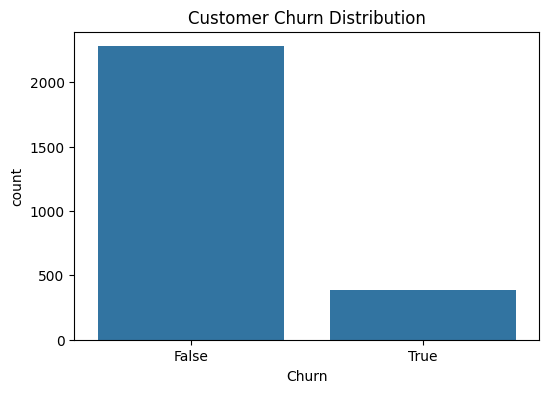

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title("Customer Churn Distribution")
plt.show()

In [13]:
churn_percent = (df['Churn'].value_counts(normalize=True) * 100).round(2)
print(churn_percent)

Churn
False    85.45
True     14.55
Name: proportion, dtype: float64


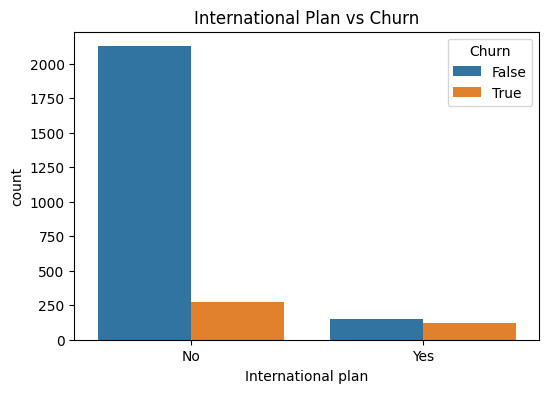

In [14]:
plt.figure(figsize=(6,4))

sns.countplot(x='International plan',
              hue='Churn',
              data=df)

plt.title("International Plan vs Churn")

plt.show()

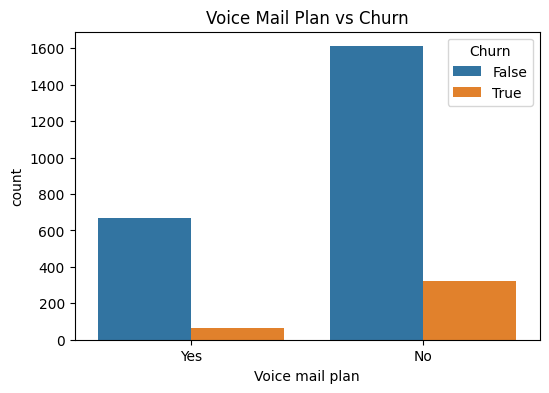

In [15]:
plt.figure(figsize=(6,4))

sns.countplot(x='Voice mail plan',
              hue='Churn',
              data=df)

plt.title("Voice Mail Plan vs Churn")

plt.show()

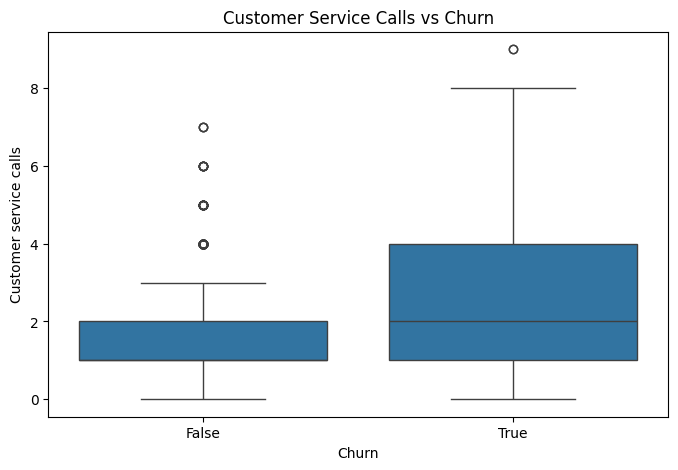

In [16]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',
            y='Customer service calls',
            data=df)

plt.title("Customer Service Calls vs Churn")

plt.show()

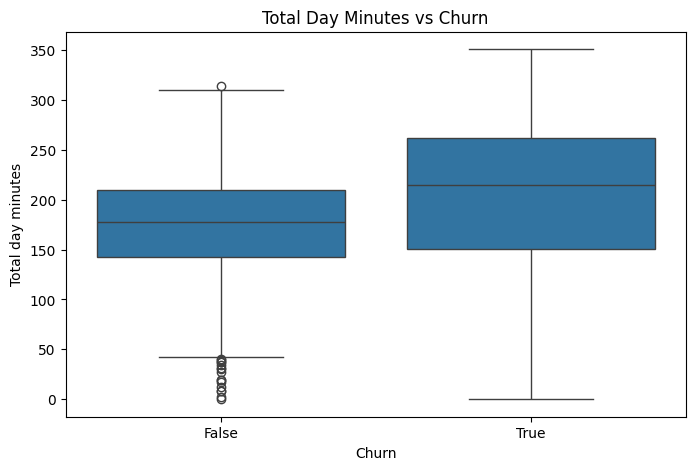

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn',
            y='Total day minutes',
            data=df)

plt.title("Total Day Minutes vs Churn")

plt.show()

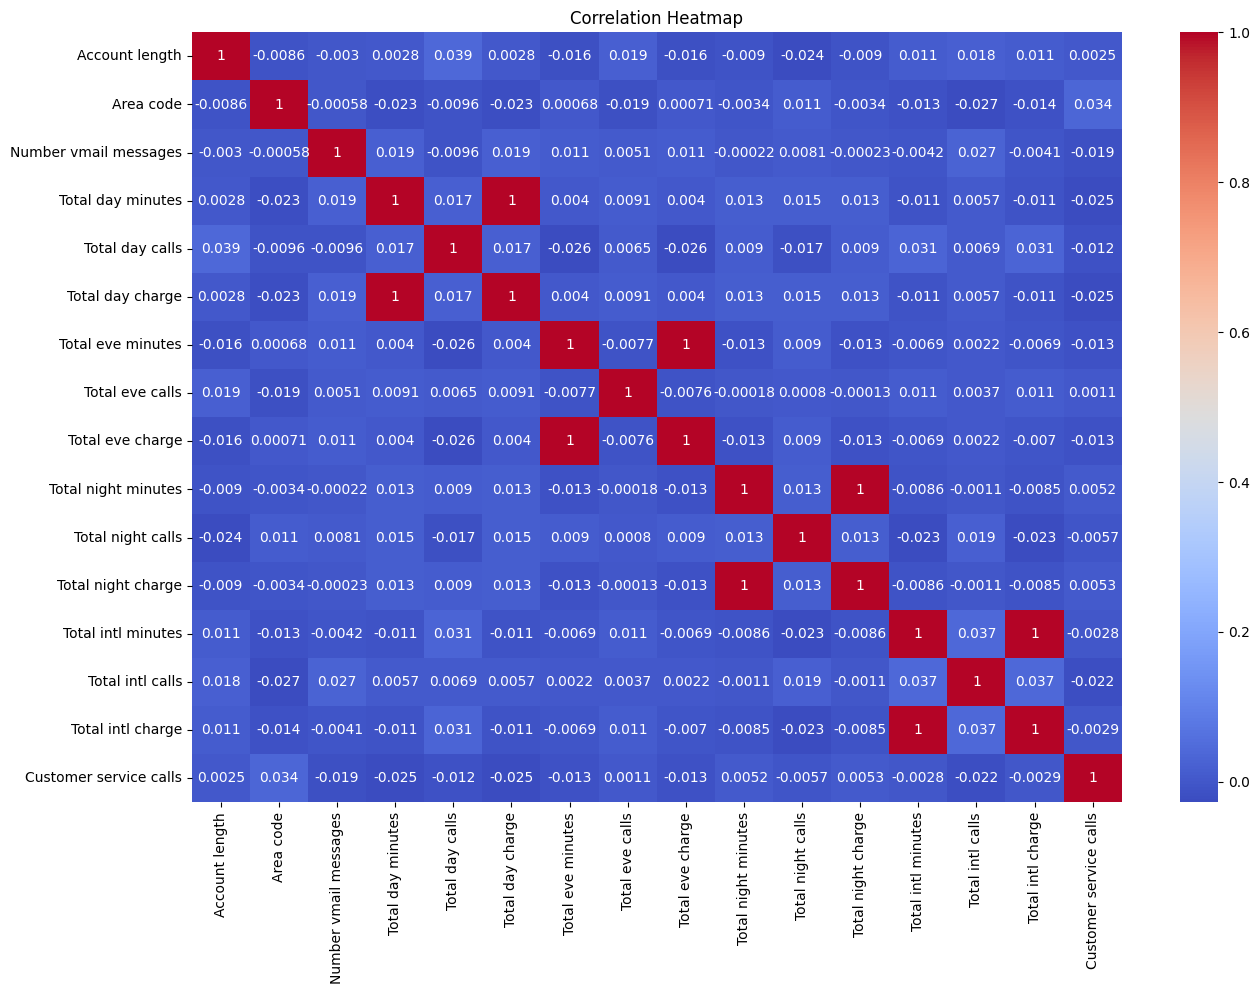

In [18]:
plt.figure(figsize=(15,10))

numeric_df = df.select_dtypes(include=['int64','float64'])

sns.heatmap(numeric_df.corr(),
            annot=True,
            cmap='coolwarm')

plt.title("Correlation Heatmap")

plt.show()

In [19]:
from sklearn.preprocessing import LabelEncoder

# Create a copy
df_ml = df.copy()

# Encode categorical columns
le = LabelEncoder()

for col in df_ml.select_dtypes(include='object').columns:
    df_ml[col] = le.fit_transform(df_ml[col])

df_ml.head()

,State,Account length,Area code,International plan,Voice mail plan,Number vmail messages,Total day minutes,Total day calls,Total day charge,Total eve minutes,Total eve calls,Total eve charge,Total night minutes,Total night calls,Total night charge,Total intl minutes,Total intl calls,Total intl charge,Customer service calls,Churn
0,16,128,415,0,1,25,265.1,110,45.07,197.4,99,16.78,244.7,91,11.01,10.0,3,2.70,1,False
1,35,107,415,0,1,26,161.6,123,27.47,195.5,103,16.62,254.4,103,11.45,13.7,3,3.70,1,False
2,31,137,415,0,0,0,243.4,114,41.38,121.2,110,10.30,162.6,104,7.32,12.2,5,3.29,0,False
3,35,84,408,1,0,0,299.4,71,50.90,61.9,88,5.26,196.9,89,8.86,6.6,7,1.78,2,False
4,36,75,415,1,0,0,166.7,113,28.34,148.3,122,12.61,186.9,121,8.41,10.1,3,2.73,3,False


In [20]:
df_ml.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2666 entries, 0 to 2665
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   State                   2666 non-null   int64  
 1   Account length          2666 non-null   int64  
 2   Area code               2666 non-null   int64  
 3   International plan      2666 non-null   int64  
 4   Voice mail plan         2666 non-null   int64  
 5   Number vmail messages   2666 non-null   int64  
 6   Total day minutes       2666 non-null   float64
 7   Total day calls         2666 non-null   int64  
 8   Total day charge        2666 non-null   float64
 9   Total eve minutes       2666 non-null   float64
 10  Total eve calls         2666 non-null   int64  
 11  Total eve charge        2666 non-null   float64
 12  Total night minutes     2666 non-null   float64
 13  Total night calls       2666 non-null   int64  
 14  Total night charge      2666 non-null   

In [21]:
X = df_ml.drop('Churn', axis=1)

y = df_ml['Churn']

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [23]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [24]:
y_pred = lr.predict(X_test)

In [25]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8558052434456929


In [26]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.88      0.96      0.92       455
        True       0.53      0.23      0.32        79

    accuracy                           0.86       534
   macro avg       0.70      0.60      0.62       534
weighted avg       0.83      0.86      0.83       534



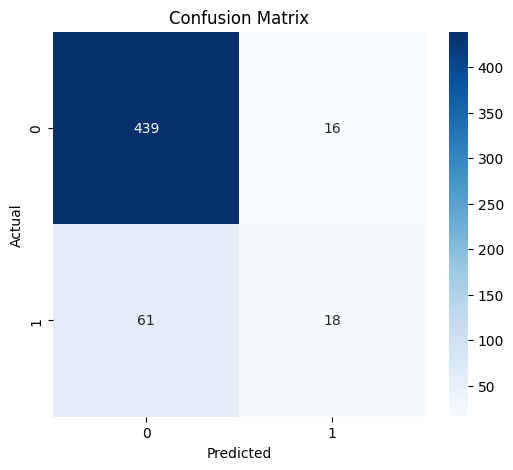

In [27]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

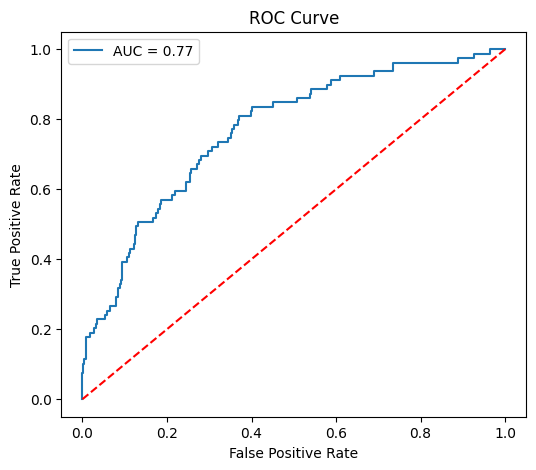

In [28]:
from sklearn.metrics import roc_curve, auc

y_prob = lr.predict_proba(X_test)[:,1]

fpr, tpr, threshold = roc_curve(y_test, y_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6,5))

plt.plot(fpr, tpr, label='AUC = %.2f' % roc_auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

## Machine Learning Summary

- Logistic Regression model was trained to predict customer churn.
- The model achieved good accuracy in distinguishing churned and retained customers.
- The confusion matrix and ROC curve indicate satisfactory classification performance.

In [29]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [30]:
dt_pred = dt.predict(X_test)

print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))

Decision Tree Accuracy: 0.9026217228464419


In [31]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

       False       0.94      0.95      0.94       455
        True       0.68      0.63      0.66        79

    accuracy                           0.90       534
   macro avg       0.81      0.79      0.80       534
weighted avg       0.90      0.90      0.90       534



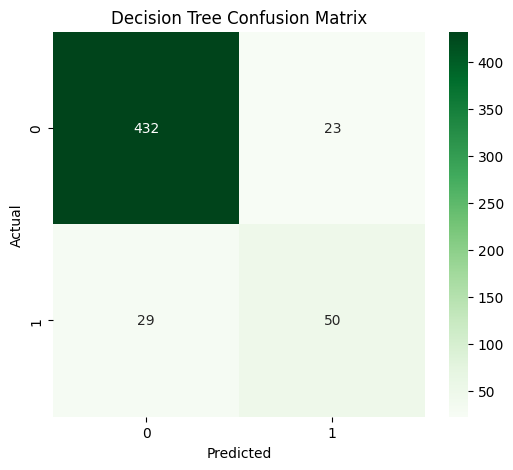

In [32]:
cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Greens')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree Confusion Matrix")

plt.show()

In [33]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': dt.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
6,Total day minutes,0.138941
18,Customer service calls,0.100484
9,Total eve minutes,0.100376
3,International plan,0.097420
15,Total intl minutes,0.096945
8,Total day charge,0.092306
16,Total intl calls,0.083983
11,Total eve charge,0.056112
4,Voice mail plan,0.050430
7,Total day calls,0.034632


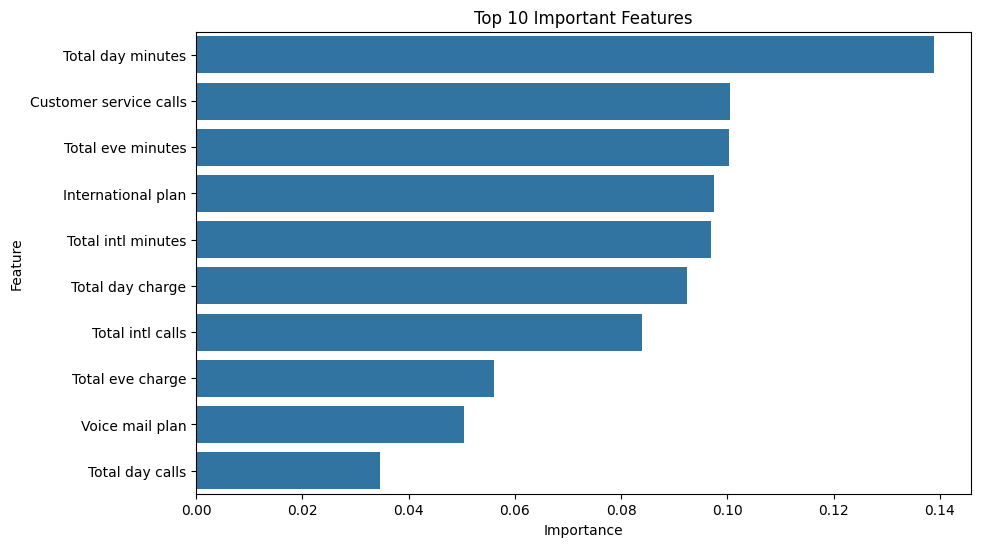

In [34]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance.head(10),
    x='Importance',
    y='Feature'
)

plt.title("Top 10 Important Features")

plt.show()

In [35]:
!pip install shap

In [36]:
import shap

explainer = shap.TreeExplainer(dt)

shap_values = explainer.shap_values(X_test)


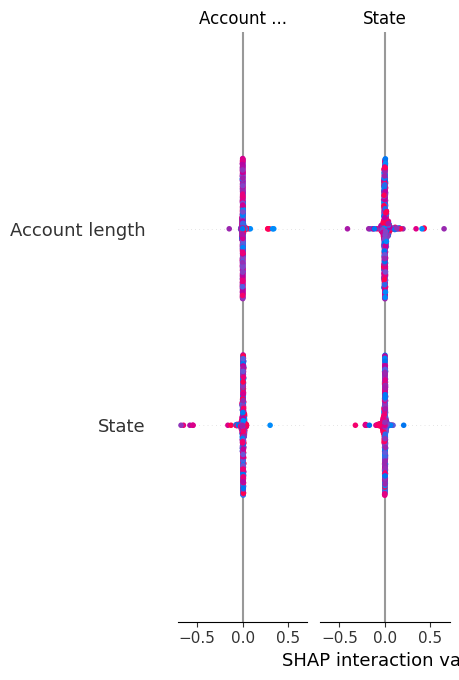

In [37]:
shap.summary_plot(shap_values, X_test)

In [38]:
prob = lr.predict_proba(X)[:,1]

df_ml['Churn Probability'] = prob

In [39]:
def segment(prob):
    if prob >= 0.70:
        return "At Risk"
    elif prob >= 0.40:
        return "Dormant"
    else:
        return "Loyal"

df_ml["Customer Segment"] = df_ml["Churn Probability"].apply(segment)

df_ml[["Customer Segment","Churn Probability"]].head()

,Customer Segment,Churn Probability
0,Loyal,0.115981
1,Loyal,0.036469
2,Loyal,0.066484
3,Dormant,0.698412
4,Dormant,0.614917


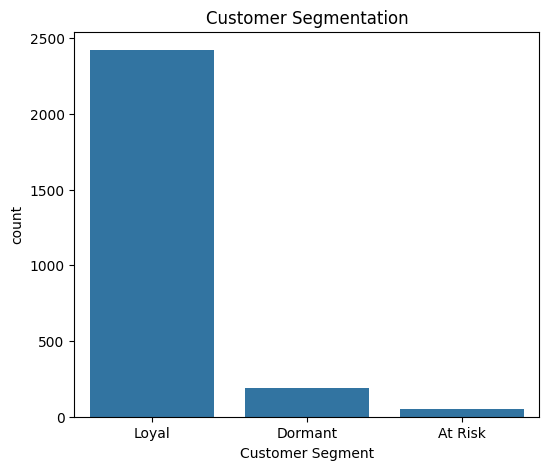

In [40]:
plt.figure(figsize=(6,5))

sns.countplot(
    x='Customer Segment',
    data=df_ml,
    order=['Loyal','Dormant','At Risk']
)

plt.title("Customer Segmentation")

plt.show()

# Business Recommendations

- Customers making frequent customer service calls should receive proactive support.
- Customers with an International Plan showed a higher likelihood of churn and should receive targeted retention offers.
- Customers identified as "At Risk" should be contacted with personalized discounts or loyalty programs.
- Customers with high day-minute usage can be offered customized plans to improve satisfaction.
- Continuous monitoring of churn probability can help reduce customer attrition and improve retention.

# Conclusion

This project successfully analyzed customer churn in the telecom industry using machine learning techniques.

Key achievements:
- Performed data cleaning and exploratory data analysis.
- Built Logistic Regression and Decision Tree models to predict churn.
- Evaluated model performance using Accuracy, Classification Report, Confusion Matrix, and ROC Curve.
- Applied SHAP explainability to understand important factors influencing churn.
- Segmented customers into Loyal, Dormant, and At Risk categories.
- Proposed business recommendations to improve customer retention.

The project demonstrates how data analytics and machine learning can help telecom companies reduce customer churn and support better business decisions.